In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv("/Users/mac1/Downloads/oil_sales_assignment_dataset - oil_sales_assignment_dataset.csv")
print(df.head())
print(df.tail())

       city                                         store_name  \
0   AL BAHA   HM No  57296  GS-CENTER-AL BAHA MAIN RD  AL BAHA   
1  AL KHARJ  HM No  55697  GS-CENTER-AL KHARJ MAIN RD  AL K...   
2    RIYADH     HM No  86781  GS-CENTER-RIYADH MAIN RD  RIYADH   
3    DAMMAM     HM No  95753  GS-CENTER-DAMMAM MAIN RD  DAMMAM   
4     JAZAN       HM No  56338  GS-CENTER-JAZAN MAIN RD  JAZAN   

          manufacturer   brand      class   size  \
0           NOVA FOODS    LARA    COCONUT  0.75L   
1   PALM & GRAIN GROUP   NAJMA     CANOLA   0.5L   
2  AL HILAL INDUSTRIES  BAYTNA  SUNFLOWER  0.75L   
3   PALM & GRAIN GROUP    NOUR       CORN   0.6L   
4        DESERT SUN CO    NOUR  VEGETABLE     1L   

                            sku price_bracket  year  month  value_sales  \
0  LARA COCONUT 0.75L TWIN PACK         21-30  2024     12       830.86   
1   NAJMA CANOLA 0.5L TWIN PACK         41-50  2024     10       373.10   
2    BAYTNA SUNFLOWER 0.75L ECO          101+  2023      1       

In [3]:
# There are 2000 rows and 13 columns. 
# Categorical: city, store_name, manufacturer, brand, class, size, sku, price_bracket
# Numerical: year, month, value_sales, volume_sales, average_price 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           2000 non-null   str    
 1   store_name     2000 non-null   str    
 2   manufacturer   2000 non-null   str    
 3   brand          2000 non-null   str    
 4   class          2000 non-null   str    
 5   size           2000 non-null   str    
 6   sku            2000 non-null   str    
 7   price_bracket  2000 non-null   str    
 8   year           2000 non-null   int64  
 9   month          2000 non-null   int64  
 10  value_sales    2000 non-null   float64
 11  volume_sales   2000 non-null   float64
 12  average_price  2000 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 203.2 KB


In [4]:
# There is no missing value
df.isna().sum()



city             0
store_name       0
manufacturer     0
brand            0
class            0
size             0
sku              0
price_bracket    0
year             0
month            0
value_sales      0
volume_sales     0
average_price    0
dtype: int64

In [5]:
df.describe()

,year,month,value_sales,volume_sales,average_price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2022.990500,6.639500,614.839355,9.972100,60.990230
std,0.820211,3.468942,750.794991,9.862369,29.457029
min,2022.000000,1.000000,6.960000,0.500000,11.000000
25%,2022.000000,4.000000,132.000000,2.900000,37.337500
50%,2023.000000,7.000000,368.320000,7.000000,61.000000
75%,2024.000000,10.000000,794.100000,13.800000,81.000000
max,2024.000000,12.000000,6253.200000,81.700000,140.000000


In [6]:
cat_cols = [
    'city', 'store_name', 'manufacturer', 'brand', 'class', 'size', 'sku', 'price_bracket'  
]
encoder = LabelEncoder()
for col in cat_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

In [7]:
x = df[['average_price']]
y = df['value_sales']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2, random_state=42
)

In [8]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[10.51]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['average_price']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-27.28
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [9]:
# Train
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[10.51]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['average_price']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-27.28
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [10]:
print(model.coef_[0])
print(model.intercept_)
print("value_Sales = ", model.coef_[0], "* average_price + ", model.intercept_)

10.50790977366243
-27.280591541652143
value_Sales =  10.50790977366243 * average_price +  -27.280591541652143


In [11]:
# predict
y_pred = model.predict(x_test)


In [12]:
# evaluate
rmse_lln = np.sqrt(mean_squared_error(y_test,y_pred))
r2_lln = r2_score(y_test, y_pred)
print("RMSE: ", rmse_lln)
print("R2_Score: ", r2_lln)


RMSE:  674.0336191200047
R2_Score:  0.13802212065425434


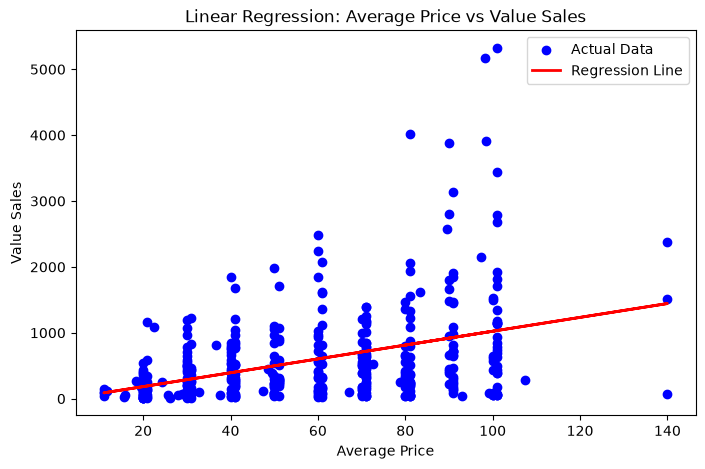

In [13]:
# Visualize using Linear regression
plt.figure(figsize=(8,5))
plt.scatter(x_test, y_test, color='blue', label='Actual Data')
plt.plot(x_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Average Price")
plt.ylabel("Value Sales")
plt.title("Linear Regression: Average Price vs Value Sales")
plt.legend()
plt.show()

In [16]:
# Linear , label encoder , scalar scaling
df.info()
x = df[['average_price',
        'volume_sales',
        'year',
        'month',
        'city',
        'manufacturer',
        'brand',
        'class',
        'price_bracket']]

y = df['value_sales']

x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           2000 non-null   int64  
 1   store_name     2000 non-null   int64  
 2   manufacturer   2000 non-null   int64  
 3   brand          2000 non-null   int64  
 4   class          2000 non-null   int64  
 5   size           2000 non-null   int64  
 6   sku            2000 non-null   int64  
 7   price_bracket  2000 non-null   int64  
 8   year           2000 non-null   int64  
 9   month          2000 non-null   int64  
 10  value_sales    2000 non-null   float64
 11  volume_sales   2000 non-null   float64
 12  average_price  2000 non-null   float64
dtypes: float64(3), int64(10)
memory usage: 203.2 KB


In [17]:
# Train
model = LinearRegression()
model.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[295.37,626.82, 0.43,..., 1.81, -6.11, -9.36]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,617.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[46.26,42.27,41.06,...,38.93,38.4 ,32.78]"


In [19]:
print("Intercept:", model.intercept_)

coef_df = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_
    })
coef_df['Absolute Coefficient'] = coef_df['Coefficient'].abs()

coef_abs = coef_df.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

print(coef_df["Absolute Coefficient"])


Intercept: 617.1289937499998
0    295.369425
1    626.818419
2      0.426157
3      8.327633
4     10.495241
5      2.810432
6      1.813375
7      6.106760
8      9.361265
Name: Absolute Coefficient, dtype: float64


In [21]:
# predict and evaluate
y_pred = model.predict(x_test_scaled)

rmse_lls = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lls = r2_score(y_test, y_pred)

print("RMSE:", rmse_lls)
print("R2 Score:", r2_lls)

RMSE: 296.4672826865719
R2 Score: 0.8332420493793089


In [ ]:
print("Intercept:", model.intercept_)

coef_df = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_
    })
coef_df['Absolute Coefficient'] = coef_df['Coefficient'].abs()

coef_abs = coef_df.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

print(coef_df["Absolute Coefficient"])


Intercept: 617.1289937499998
0    295.369425
1    626.818419
2      0.426157
3      8.327633
4     10.495241
5      2.810432
6      1.813375
7      6.106760
8      9.361265
Name: Absolute Coefficient, dtype: float64


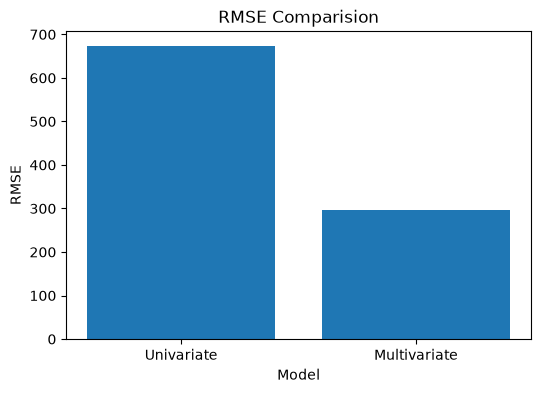

In [23]:
#Bar graph for both 
comparision = pd.DataFrame({
    'Model': ['Univariate', 'Multivariate'],
    'RMSE': [674, 296],
    'R2': [0.13, 0.83]
})
plt.figure(figsize=(6,4))
plt.bar(comparision['Model'], comparision['RMSE'])
plt.title("RMSE Comparision")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

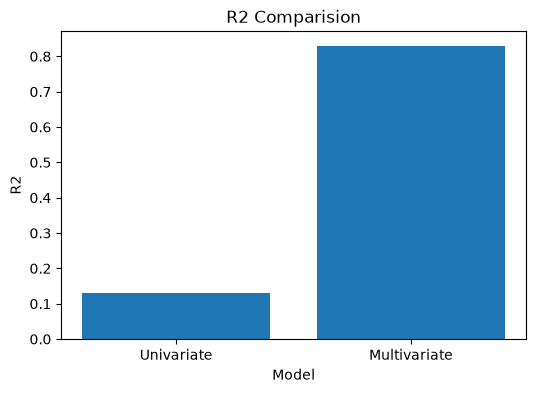

In [24]:
#Bar graph for both 

plt.figure(figsize=(6,4))
plt.bar(comparision['Model'], comparision['R2'])
plt.title("R2 Comparision")
plt.xlabel("Model")
plt.ylabel("R2")
plt.show()